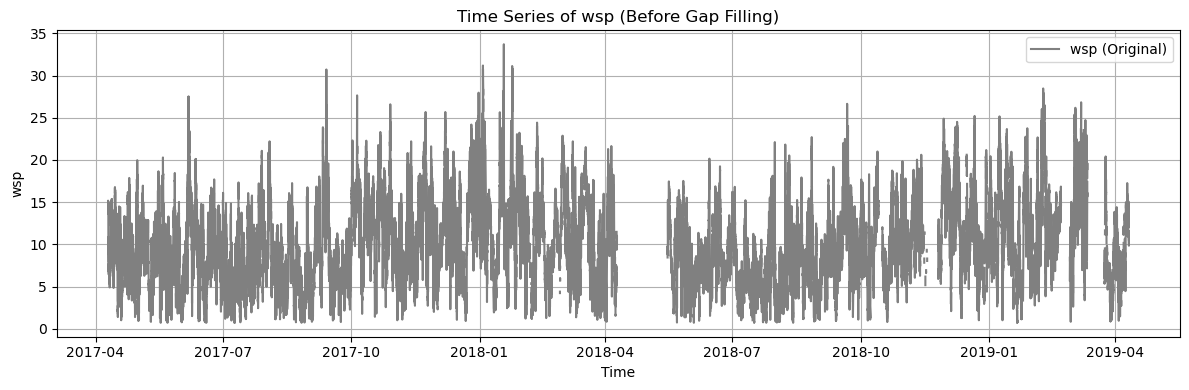

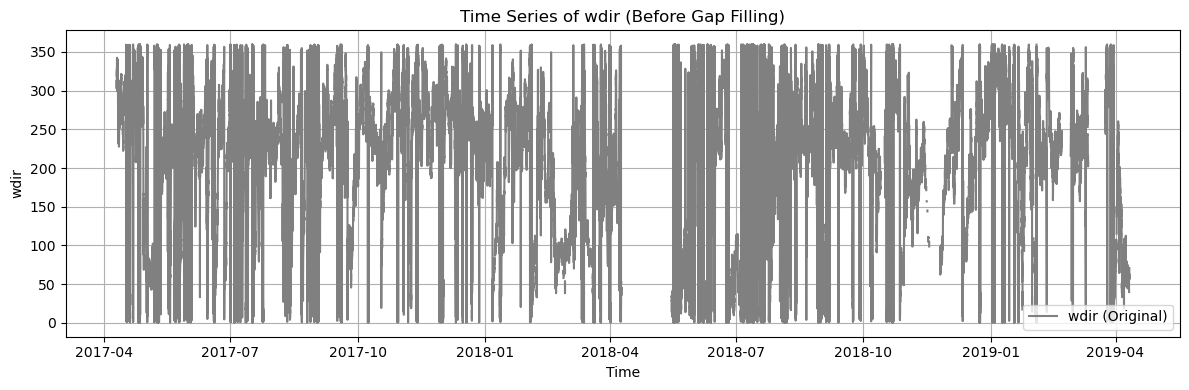

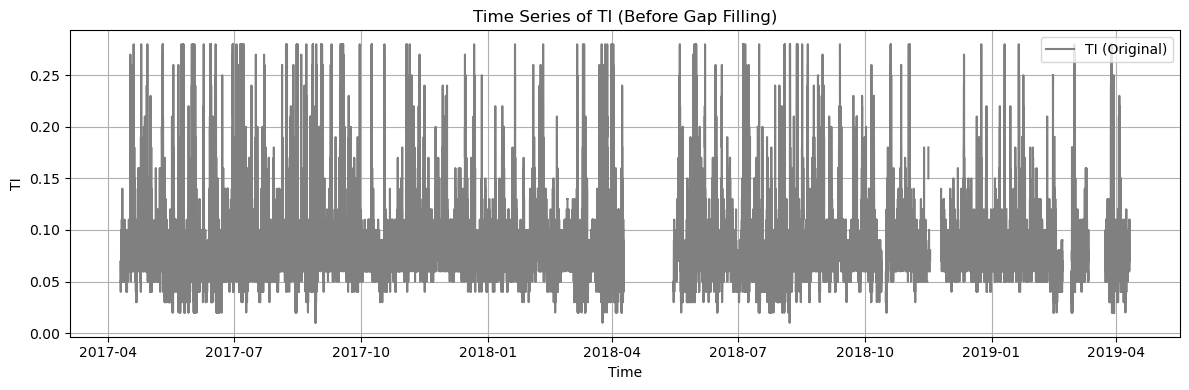

Interpolated data saved to M:\Projects\Cost Model\VP_loadframework\sudoco_task2.3\data\timeseries\HKNB_timeseries_full_filled.csv


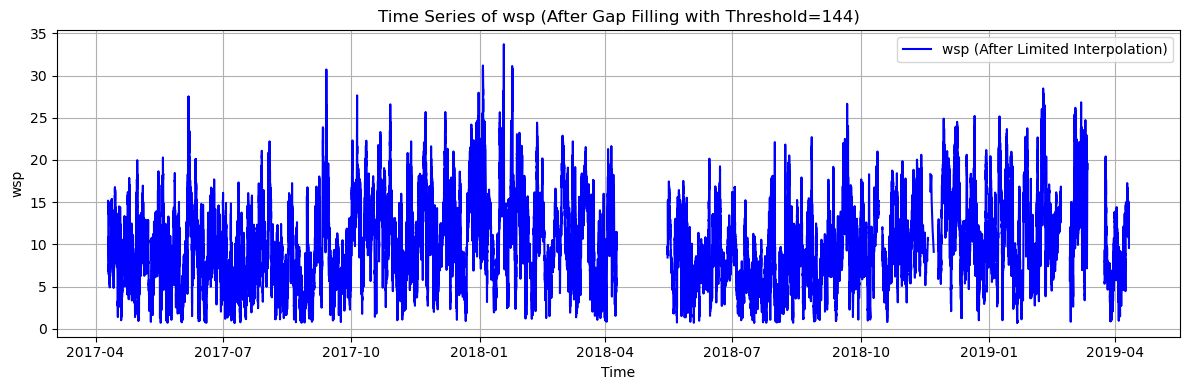

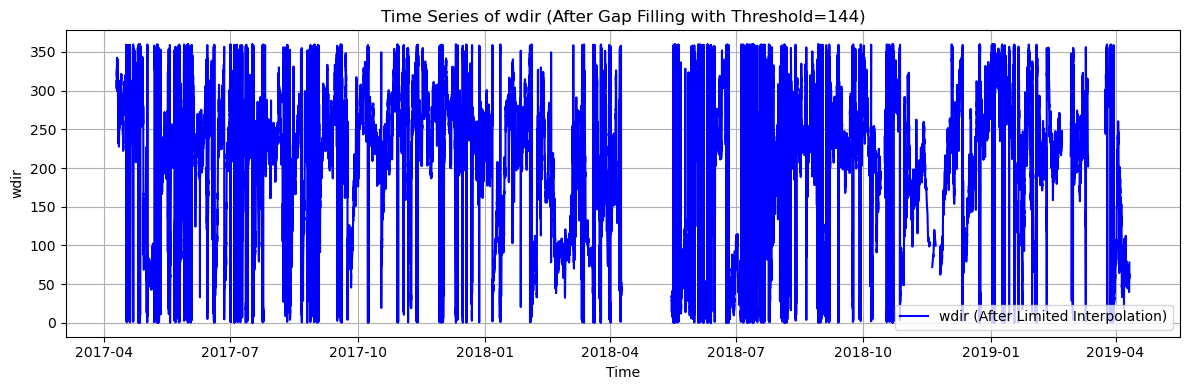

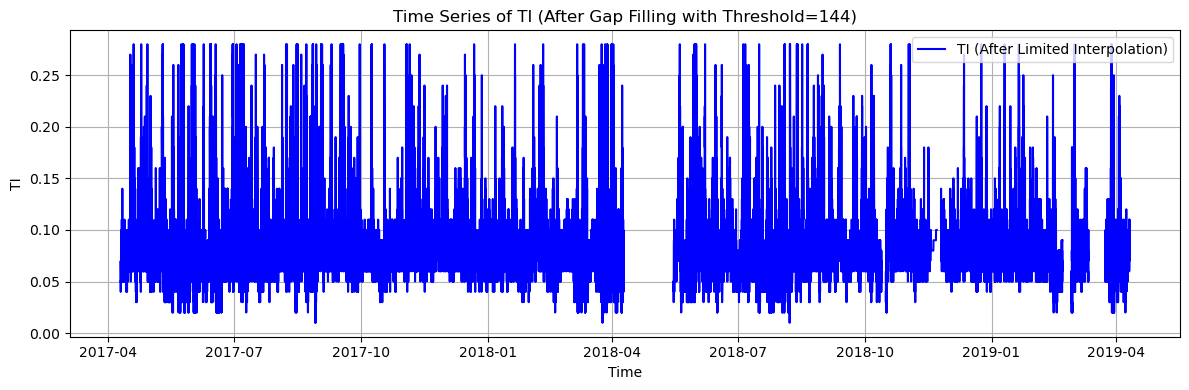

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Read the CSV file
file_path = 'M:\\Projects\\Cost Model\\VP_loadframework\\sudoco_task2.3\\data\\timeseries\\HKNB_timeseries_full.csv'
df = pd.read_csv(file_path)

# Step 1.5: Convert the datetime column (if applicable)
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Step 1.6: Copy original data
df_original = df.copy()

# Step 2: Plot original time series
channels = ['wsp', 'wdir', 'TI']
time_column = 'timestamp' if 'timestamp' in df.columns else df.index

for channel in channels:
    plt.figure(figsize=(12, 4))
    plt.plot(df_original[time_column], df_original[channel], label=f'{channel} (Original)', color='gray')
    plt.title(f'Time Series of {channel} (Before Gap Filling)')
    plt.xlabel('Time')
    plt.ylabel(channel)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Step 3: Apply conditional gap filling based on max_gap_threshold
def interpolate_limited(series, max_gap):
    """Interpolate only if consecutive NaNs <= max_gap."""
    series = series.copy()
    is_nan = series.isna()
    group = (is_nan != is_nan.shift()).cumsum()  # Change group on each transition
    result = series.copy()

    for grp, values in series.groupby(group):
        if is_nan.loc[values.index[0]]:  # Only process NaN groups
            gap_length = len(values)
            if gap_length <= max_gap:
                # Fill only this small gap
                result.loc[values.index] = series.interpolate(method='linear').loc[values.index]
            # Else: leave as NaN
    return result.round(2)

# Threshold for max consecutive NaNs to interpolate
max_gap_threshold = 144  # Change as needed

# Apply gap filling with limit
for channel in channels:
    df[channel] = interpolate_limited(df[channel], max_gap_threshold)

# Step 4: Save cleaned data
output_path = 'M:\\Projects\\Cost Model\\VP_loadframework\\sudoco_task2.3\\data\\timeseries\\HKNB_timeseries_full_filled.csv'
df.to_csv(output_path, index=False)
print(f"Interpolated data saved to {output_path}")

# Step 5: Plot after conditional interpolation
for channel in channels:
    plt.figure(figsize=(12, 4))
    plt.plot(df[time_column], df[channel], label=f'{channel} (After Limited Interpolation)', color='blue')
    plt.title(f'Time Series of {channel} (After Gap Filling with Threshold={max_gap_threshold})')
    plt.xlabel('Time')
    plt.ylabel(channel)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
